# 📊 Retail Sales Performance Analysis
### A Complete Data Analytics Project using Python (Pandas, NumPy, Matplotlib, Seaborn)

**Objective:**
- Analyze retail sales data (loaded from a real CSV file) to uncover trends, patterns, and business insights.
- Practice the full data analysis workflow: **load data → clean → explore → visualize → conclude**.

**Tools used (only):**
- **Pandas** — reading the CSV and manipulating data
- **NumPy** — numerical operations and statistics
- **Matplotlib** — plotting
- **Seaborn** — statistical visualizations

**Dataset:** `retail_sales_data.csv` — make sure this file is in the **same folder** as this notebook before running.


In [4]:
# Import pandas for reading the CSV and working with tabular data
import pandas as pd

# Import numpy for numerical operations (arrays, statistics)
import numpy as np

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Import seaborn for nicer statistical charts (built on top of matplotlib)
import seaborn as sns
# Set a clean visual theme for all seaborn/matplotlib charts
sns.set_style("whitegrid")

# Set a default figure size so charts are not too small
plt.rcParams['figure.figsize'] = (10, 5)

# Tell pandas to show all columns when printing a dataframe (not truncated)
pd.set_option('display.max_columns', None)

# Confirmation message once imports are done
print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Dataset from CSV

- We use `pd.read_csv()` to load `retail_sales_data.csv` into a pandas DataFrame.
- Columns: `Order_Date`, `Region`, `Category`, `Sub_Category`, `Customer_Segment`, `Sales`, `Quantity`, `Discount`, `Profit`.

**Try it:** Change `df.head()` to `df.head(10)` to preview more rows.


In [5]:
# Read the CSV file into a pandas DataFrame called df
df = pd.read_csv(r"C:\Users\Asus\Downloads\retail_sales_data.csv")

# Convert the Order_Date column from plain text into an actual datetime type
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Print the shape (rows, columns) of the dataset so we know its size
print("Dataset shape:", df.shape)

# Display the first 5 rows to get a quick look at the data
df.head()


Dataset shape: (2015, 9)


,Order_Date,Region,Category,Sub_Category,Customer_Segment,Sales,Quantity,Discount,Profit
0,2023-09-08,South,Furniture,Bookcases,Consumer,112.57,7,0.0,61.69
1,2024-04-05,North,Furniture,Tables,Consumer,129.52,12,0.0,78.58
2,2024-02-23,West,Technology,Laptops,Home Office,176.92,7,0.2,23.02
3,2023-05-31,East,Furniture,Tables,Home Office,476.82,2,0.2,84.97
4,2023-04-12,South,Office Supplies,Paper,Consumer,175.90,1,0.2,34.49


## 2. Explore the Dataset (Data Overview)

- **`.info()`** tells us column types and non-null counts.
- **`.describe()`** gives statistical summary (mean, std, min, max, quartiles).
- **`.isnull().sum()`** shows exact missing values per column.

**Try it:** Run `df.describe(include='object')` to see summary stats for the text (categorical) columns instead of numeric ones.


In [6]:
# Print a header for clarity in the output
print("----- Dataset Info -----")

# Show column names, data types, and how many non-missing values each column has
df.info()


----- Dataset Info -----
<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_Date        2015 non-null   datetime64[us]
 1   Region            2015 non-null   str           
 2   Category          2015 non-null   str           
 3   Sub_Category      2015 non-null   str           
 4   Customer_Segment  2015 non-null   str           
 5   Sales             1974 non-null   float64       
 6   Quantity          2015 non-null   int64         
 7   Discount          2015 non-null   float64       
 8   Profit            1990 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 141.8 KB


In [7]:
# Print a header for clarity in the output
print("----- Statistical Summary -----")

# Generate summary statistics (count, mean, std, min, max, quartiles) for numeric columns
df.describe()


----- Statistical Summary -----


,Order_Date,Sales,Quantity,Discount,Profit
count,2015,1974.000000,2015.000000,2015.000000,1990.000000
mean,2023-12-23 14:13:16.823821,267.503541,7.615385,0.116774,62.543251
min,2023-01-01 00:00:00,20.010000,1.000000,0.000000,-82.000000
25%,2023-06-15 12:00:00,90.532500,4.000000,0.000000,15.577500
50%,2023-12-16 00:00:00,188.015000,8.000000,0.100000,41.590000
75%,2024-06-27 12:00:00,358.325000,11.000000,0.200000,85.692500
max,2024-12-31 00:00:00,1854.750000,14.000000,0.400000,638.490000
std,NaN,248.491085,4.044988,0.118525,73.908991


In [8]:
# Print a header before showing missing value counts
print("----- Missing Values per Column -----")

# Count how many missing (NaN) values exist in each column
print(df.isnull().sum())

# Print a blank line then a header for duplicate check
print("\n----- Duplicate Rows -----")

# Count how many fully duplicated rows exist in the dataset
print("Number of duplicate rows:", df.duplicated().sum())


----- Missing Values per Column -----
Order_Date           0
Region               0
Category             0
Sub_Category         0
Customer_Segment     0
Sales               41
Quantity             0
Discount             0
Profit              25
dtype: int64

----- Duplicate Rows -----
Number of duplicate rows: 15


## 3. Data Cleaning

- **Remove duplicate rows** using `.drop_duplicates()`.
- **Handle missing values**:
  - `Sales` → fill missing values with the **median** (robust to outliers).
  - `Profit` → fill missing values with the **mean**.
- **Create new columns** for deeper analysis:
  - `Profit_Margin` = Profit / Sales
  - `Order_Month`, `Order_Year`, `Month_Name` extracted from `Order_Date`.

**Try it:** Instead of filling `Sales` with the overall median, try `df.groupby('Category')['Sales'].transform('median')` — a category-wise median. Compare the results.


In [9]:
# Store the number of rows before removing duplicates (for comparison later)
before = df.shape[0]

# Remove duplicate rows and reset the row index so it stays clean (0,1,2,...)
df = df.drop_duplicates().reset_index(drop=True)

# Store the number of rows after removing duplicates
after = df.shape[0]

# Print how many duplicate rows were removed
print(f"We Removed The {before - after} duplicate rows.")


We Removed The 15 duplicate rows.


In [10]:
# Fill missing Sales values with the median of the Sales column (median is robust to outliers)
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

# Fill missing Profit values with the mean of the Profit column
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())

# Create a new column: Profit Margin = Profit divided by Sales, rounded to 3 decimals
df['Profit_Margin'] = df['Profit'] / df['Sales'].round(3)

# Extract the month number (1-12) from Order_Date into a new column
df["Order_Month"] = df["Order_Date"].dt.month

# Extract the year (2023/2024) from Order_Date into a new column
df["Order_Year"] = df["Order_Date"].dt.year

# Extract the short month name (Jan, Feb, ...) from Order_Date into a new column
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")

# Print total remaining missing values to confirm cleaning worked
print("Missing values after cleaning:", df.isnull().sum().sum())

# Display the first 5 rows of the cleaned dataframe with new columns
df.head()

Missing values after cleaning: 0


,Order_Date,Region,Category,Sub_Category,Customer_Segment,Sales,Quantity,Discount,Profit,Profit_Margin,Order_Month,Order_Year,Month_Name
0,2023-09-08,South,Furniture,Bookcases,Consumer,112.57,7,0.0,61.69,0.548015,9,2023,Sep
1,2024-04-05,North,Furniture,Tables,Consumer,129.52,12,0.0,78.58,0.606702,4,2024,Apr
2,2024-02-23,West,Technology,Laptops,Home Office,176.92,7,0.2,23.02,0.130115,2,2024,Feb
3,2023-05-31,East,Furniture,Tables,Home Office,476.82,2,0.2,84.97,0.178201,5,2023,May
4,2023-04-12,South,Office Supplies,Paper,Consumer,175.90,1,0.2,34.49,0.196077,4,2023,Apr


## 4. Univariate Analysis — Distribution of Key Numeric Columns

- A **histogram** shows how values are spread out (e.g., are most sales small or large?).
- A **boxplot** helps us quickly spot **outliers**.


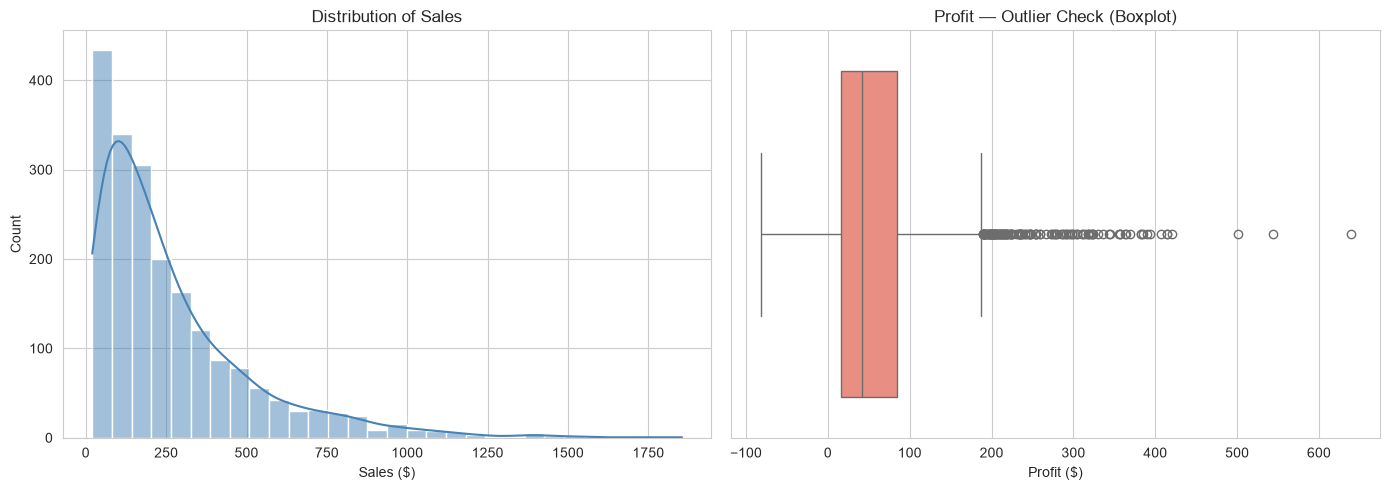

In [11]:
# Create a figure with 1 row and 2 columns of subplots, sized 14x5 inches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot a histogram of Sales with a smooth density curve (kde) on the first subplot
sns.histplot(df["Sales"], bins=30, kde=True, color="steelblue", ax=axes[0])

# Set the title for the first subplot
axes[0].set_title("Distribution of Sales")

# Label the x-axis of the first subplot
axes[0].set_xlabel("Sales ($)")

# Plot a boxplot of Profit on the second subplot to visually check for outliers
sns.boxplot(x=df["Profit"], color="salmon", ax=axes[1])

# Set the title for the second subplot
axes[1].set_title("Profit — Outlier Check (Boxplot)")

# Label the x-axis of the second subplot
axes[1].set_xlabel("Profit ($)")

# Adjust spacing so subplots don't overlap
plt.tight_layout()

# Render the figure
plt.show()


## 5. Categorical Analysis — Sales & Profit by Business Dimensions

- **Bar charts** compare a numeric value across categories.
- Here we compare total **Sales** and **Profit** across `Category` and `Region`.


In [2]:
import matplotlib.pyplot as plt


C:\Users\Asus\AppData\Local\Temp\ipykernel_3420\2603132934.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis", ax=axes[0])
C:\Users\Asus\AppData\Local\Temp\ipykernel_3420\2603132934.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Region_Profit.index,y=Region_Profit.values,palette='viridis',ax=axes[1])


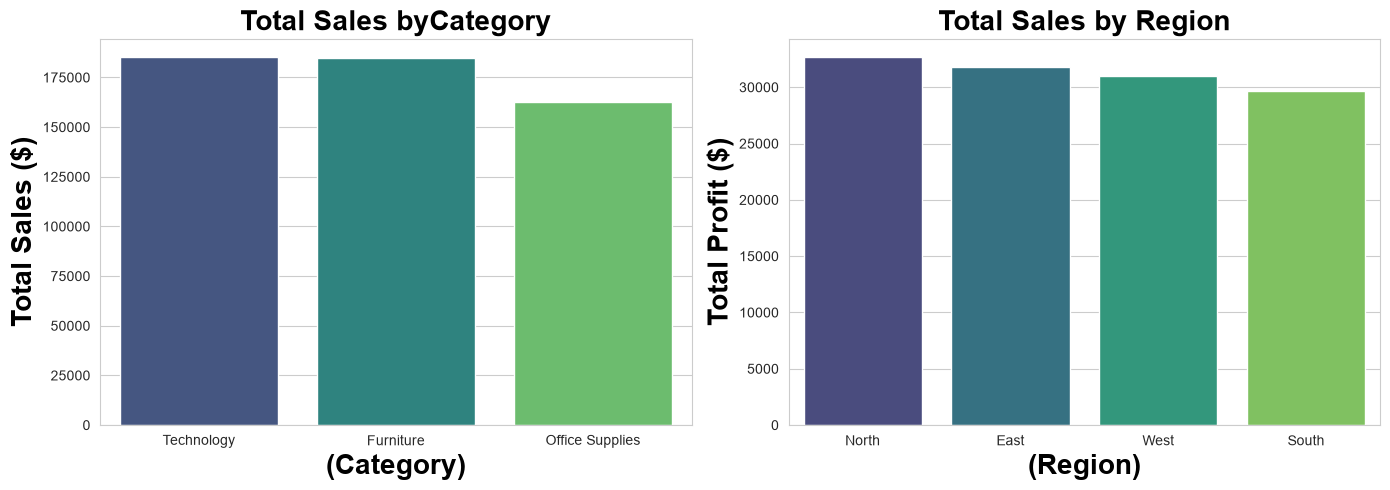

In [34]:
# Create a figure with 1 row and 2 columns of subplots
fig,axes = plt.subplots(1,2,figsize=(14,5))

# Group the data by Category and sum the Sales, then sort from highest to lowest
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Draw a bar chart of total sales per category on the first subplot
sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis", ax=axes[0])
## Important: palette mostly tab useful hai jab plot mein multiple categories hon.
## ax=axes[0]Ye batata hai ki graph kis subplot mein banana hai

# Set the title for the first subplot
axes[0].set_title("Total Sales byCategory",fontsize = 20, color = 'k',fontweight = 'bold')

# Label the y-axis of the first subplot
axes[0].set_ylabel("Total Sales ($)",fontsize = 20, color = 'k',fontweight = 'bold')

# Label the x-axis of the first subplot
axes[0].set_xlabel("(Category)",fontsize = 20, color = 'k',fontweight = 'bold')


# Group the data by Region and sum the Profit, then sort from highest to lowest
Region_Profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

# Draw a bar chart of total profit per region on the second subplot
sns.barplot(x=Region_Profit.index,y=Region_Profit.values,palette='viridis',ax=axes[1])

# Set the title for the second subplot
axes[1].set_title("Total Sales by Region",fontsize = 20, color = 'k',fontweight = 'bold')

# Label the y-axis of the second subplot
axes[1].set_ylabel("Total Profit ($)",fontsize = 20, color = 'k',fontweight = 'bold')

# Label the x-axis of the second subplot
axes[1].set_xlabel("(Region)",fontsize = 20, color = 'k',fontweight = 'bold')

# Adjust spacing so subplots don't overlap
plt.tight_layout()

# Render the figure
plt.show()

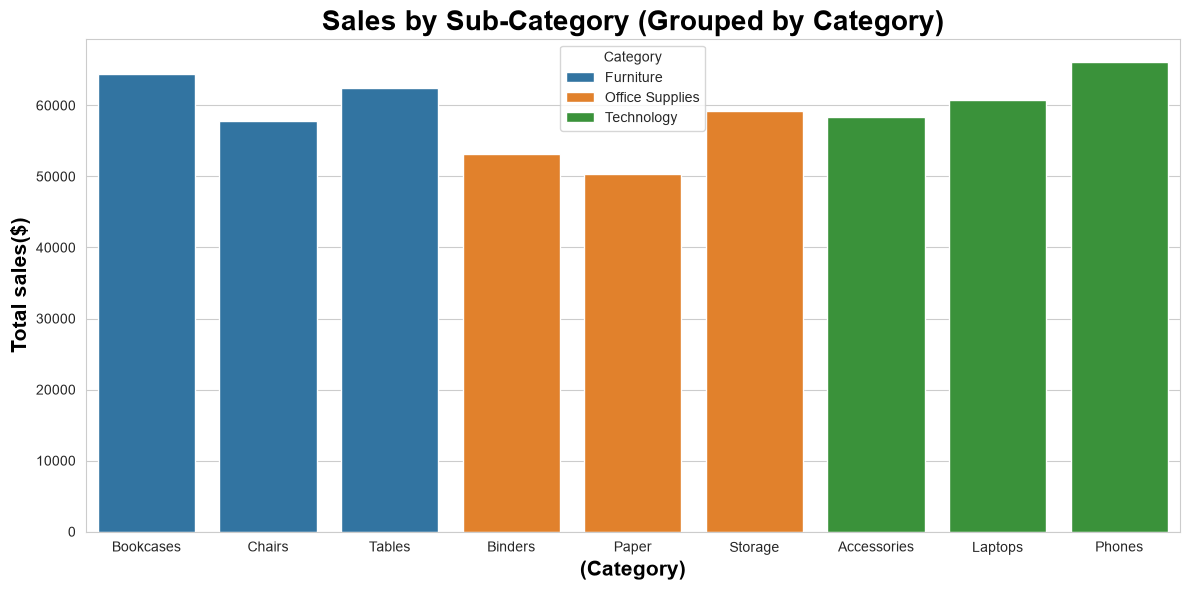

In [57]:
# Set the figure size for this chart
plt.figure(figsize=(12, 6))

# Group by both Category and Sub_Category, summing Sales, then reset index to a flat table
sub_cat_sales = df.groupby(['Category','Sub_Category'])['Sales'].sum().reset_index()

# Draw a bar chart of sales per sub-category, colored by their parent category
sns.barplot(data=sub_cat_sales, x="Sub_Category", y="Sales", hue="Category", dodge=False)

# Set the chart title
plt.title("Sales by Sub-Category (Grouped by Category)",fontsize = 20, color = 'k',fontweight = 'bold')


# Rotate x-axis labels so long sub-category names don't overlap
# Label the x-axis
plt.xlabel('(Category)',fontsize = 15, color = 'k',fontweight = 'bold')
# Label the y-axis
plt.ylabel('Total sales($)',fontsize = 15, color = 'k',fontweight = 'bold')

# Adjust spacing so nothing gets cut off
plt.tight_layout()

# Render the figure
plt.show()

## 6. Time Series Analysis — Monthly Sales Trend

- We use a **line chart** to see how sales change **month by month** across both years.
- This helps identify **seasonality** — do certain months always perform better?

**Try it:** Filter with `df[df['Order_Year'] == 2023]` first, then re-plot, to see just one year's trend.


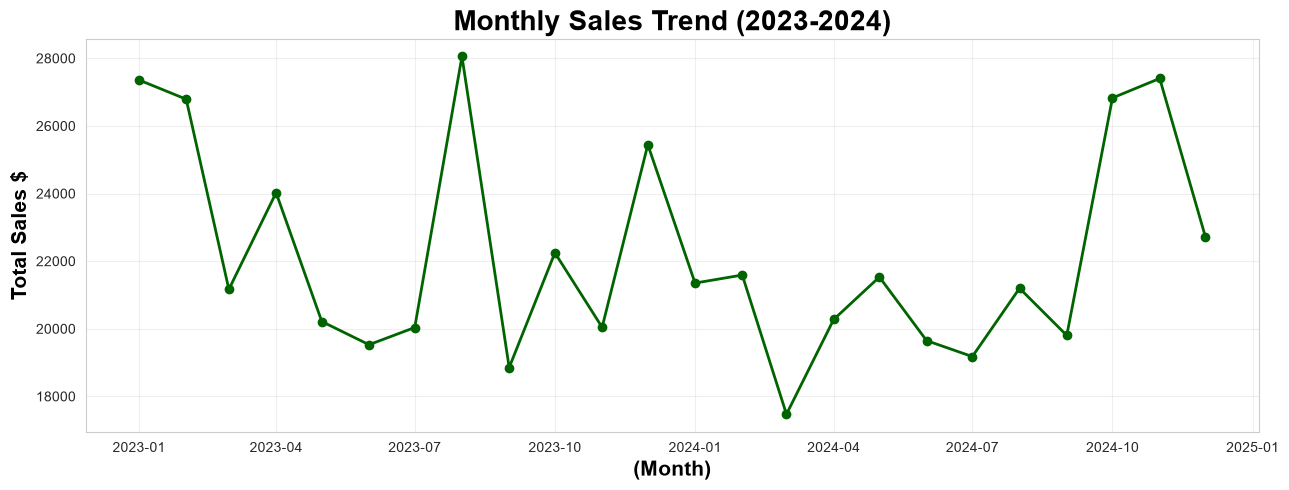

In [60]:
# Group Sales by calendar month (year+month combined) and sum them
Monthly_sales = df.groupby(df['Order_Date'].dt.to_period("M"))['Sales'].sum()

# Convert the period index (e.g. 2023-01) back into a proper timestamp for plotting
Monthly_sales.index = Monthly_sales.index.to_timestamp()

# Set the figure size for this chart
plt.figure(figsize=(13, 5))


# Plot a line chart of monthly sales with circular markers at each point
plt.plot(Monthly_sales.index, Monthly_sales.values, marker="o", color="darkgreen", linewidth=2)

# Set the chart title
plt.title("Monthly Sales Trend (2023-2024)",fontsize = 20, color = 'k',fontweight = 'bold')

# Label the x-axis
plt.xlabel('(Month)',fontsize = 15, color = 'k',fontweight = 'bold')
# Label the y-axis
plt.ylabel('Total Sales $',fontsize = 15, color = 'k',fontweight = 'bold')

# Add a light grid for easier reading of values
plt.grid(True, alpha=0.3)

# Adjust spacing so labels don't get cut off
plt.tight_layout()
# Render the figure
plt.show()


## 7. Correlation Analysis — Heatmap

- A **correlation heatmap** shows how numeric columns relate to each other.
- Values close to **+1** = strong positive relationship. Close to **-1** = strong negative relationship. Close to **0** = little/no relationship.


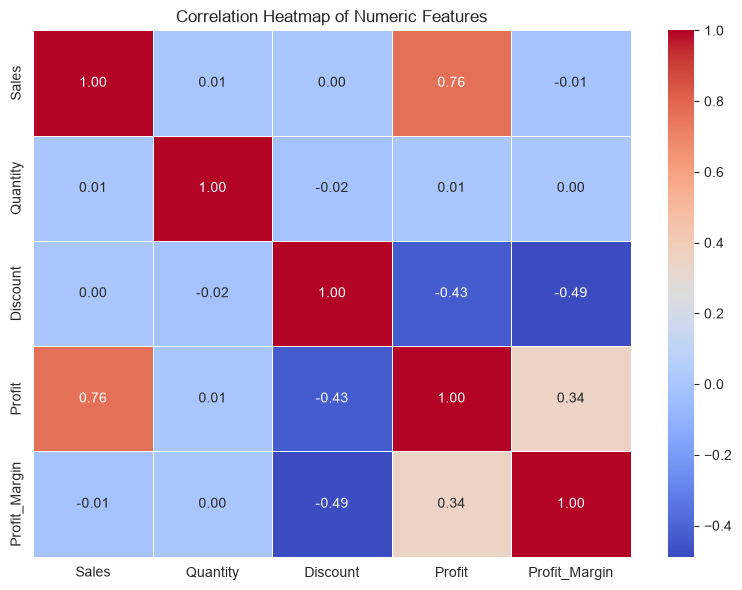

In [61]:
# List the numeric columns we want to check correlation between
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit_Margin"]

# Compute the correlation matrix for those numeric columns
corr = df[numeric_cols].corr()

# Set the figure size for the heatmap
plt.figure(figsize=(8, 6))

# Draw the heatmap with correlation values annotated on each cell
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Set the chart title
plt.title("Correlation Heatmap of Numeric Features")

# Adjust spacing so labels aren't cut off
plt.tight_layout()

# Render the figure
plt.show()


## 8. Multivariate Analysis

- **Boxplot**: Profit Margin distribution across each Category — helps compare consistency and outliers between groups.
- **Scatterplot**: Relationship between Discount and Profit — does giving more discount hurt profit?


C:\Users\Asus\AppData\Local\Temp\ipykernel_3420\1573233948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Profit_Margin", palette="Set2", ax=axes[0])


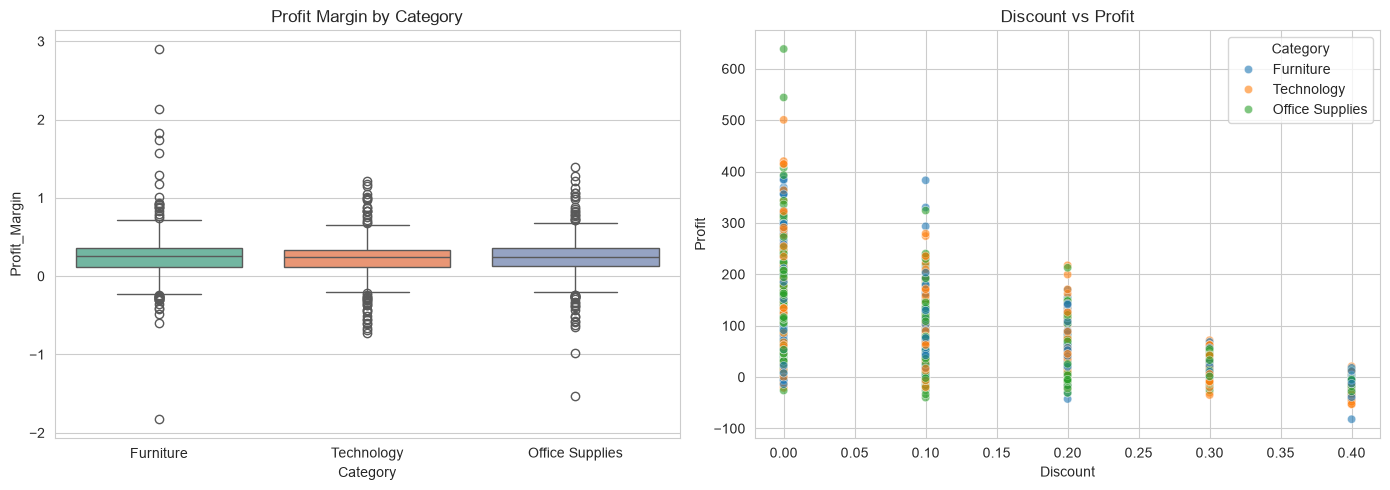

In [62]:
# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Draw a boxplot showing Profit_Margin spread for each Category on the first subplot
sns.boxplot(data=df, x="Category", y="Profit_Margin", palette="Set2", ax=axes[0])

# Set the title for the first subplot
axes[0].set_title("Profit Margin by Category")

# Draw a scatterplot of Discount vs Profit, colored by Category, on the second subplot
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.6, ax=axes[1])

# Set the title for the second subplot
axes[1].set_title("Discount vs Profit")

# Adjust spacing so subplots don't overlap
plt.tight_layout()

# Render the figure
plt.show()


## 9. Statistical Deep-Dive using NumPy

- Use **NumPy** directly for statistical calculations: mean, median, standard deviation, percentiles.
- **Outlier detection** using the **Z-score method**: any value with `|z| > 3` is considered an outlier.

**Try it:** Change the z-score threshold from `3` to `2` and see how many more points get flagged as outliers.


In [63]:
# Convert the Sales column from a pandas Series into a plain NumPy array
sales_array = df["Sales"].to_numpy()

# Calculate the mean (average) of all sales values using NumPy
mean_sales = np.mean(sales_array)

# Calculate the median (middle value) of sales using NumPy
median_sales = np.median(sales_array)

# Calculate the standard deviation (spread) of sales using NumPy
std_sales = np.std(sales_array)

# Calculate the 25th and 75th percentile values of sales using NumPy
p25, p75 = np.percentile(sales_array, [25, 75])

# Print all the calculated statistics, formatted to 2 decimal places
print(f"Mean Sales     : {mean_sales:.2f}")
print(f"Median Sales   : {median_sales:.2f}")
print(f"Std Dev Sales  : {std_sales:.2f}")
print(f"25th Percentile: {p25:.2f}")
print(f"75th Percentile: {p75:.2f}")

# Calculate the z-score for every sales value: (value - mean) / std deviation
z_scores = (sales_array - mean_sales) / std_sales

# Filter the dataframe to keep only rows where the z-score is beyond +/-3 (outliers)
outliers = df[np.abs(z_scores) > 3]

# Print how many outlier orders were found
print(f"\nNumber of outlier orders (|z| > 3): {len(outliers)}")

# Display a few key columns for the outlier rows
outliers[["Order_Date", "Category", "Sales", "Profit"]].head()


Mean Sales     : 266.37
Median Sales   : 189.06
Std Dev Sales  : 246.54
25th Percentile: 92.13
75th Percentile: 353.56

Number of outlier orders (|z| > 3): 38


,Order_Date,Category,Sales,Profit
143,2024-11-02,Office Supplies,1215.61,407.05
181,2024-10-02,Technology,1468.11,500.59
304,2023-10-29,Technology,1212.89,199.54
311,2024-05-17,Technology,1064.23,-53.16
333,2023-11-01,Office Supplies,1126.00,150.65


## 10. Key Insights & Conclusion

Based on the analysis above:

- **Technology and Furniture** tend to drive higher average sales values compared to Office Supplies.
- **Discount and Profit show a negative relationship** — higher discounts generally squeeze profit margins, visible in the scatterplot.
- **Sales show clear monthly fluctuation**, suggesting seasonal buying patterns worth investigating further.
- A small number of orders are **statistical outliers** (very high sales) — these could be bulk/corporate orders worth a separate analysis.
- **Region-wise profit** varies — some regions generate strong revenue but comparatively lower profit, hinting at higher discounting or costs in those areas.

